# Codomax Data Science Internship

# Module 6: Final Data Science Project

## Global Superstore Sales Analysis and Profit Prediction

**Internship:** Data Science Intern  
**Module:** 6  
**Domain:** Retail / Business Analytics

### Project Objective

The objective of this project is to perform an end-to-end Data Science
analysis on a real-world retail dataset.

The project includes data loading, data cleaning, exploratory data
analysis, data visualization, business insights, machine learning,
model evaluation, and final conclusions.

### Technologies Used

- Python
- Pandas
- NumPy
- Matplotlib
- Seaborn
- Scikit-learn
- Google Colab

## Project Workflow

1. Import required libraries
2. Load the dataset
3. Understand the dataset
4. Clean the data
5. Perform Exploratory Data Analysis
6. Create visualizations
7. Generate business insights
8. Prepare data for Machine Learning
9. Train Machine Learning models
10. Evaluate model performance
11. Compare models
12. Summarize findings
13. Final conclusion

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

print("All libraries imported successfully.")

All libraries imported successfully.


## 1. Loading the Dataset

The Global Superstore dataset is a real-world retail dataset containing
information about orders, customers, products, sales, discounts,
shipping, and profit.

The dataset will be loaded into a Pandas DataFrame for analysis.

In [2]:
url = "https://raw.githubusercontent.com/yannie28/Global-Superstore/master/Global_Superstore(CSV).csv"

df = pd.read_csv(url)

print("Dataset loaded successfully.")
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

Dataset loaded successfully.
Number of rows: 1000
Number of columns: 24


In [3]:
print("First 5 rows:")
display(df.head())

First 5 rows:


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Postal Code,City,...,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit,Shipping Cost,Order Priority
0,40098,CA-2014-AB10015140-41954,11/11/2014,11/13/2014,First Class,AB-100151402,Aaron Bergman,Consumer,73120.0,Oklahoma City,...,TEC-PH-5816,Technology,Phones,Samsung Convoy 3,221.98,2,0.0,62.15,40.77,High
1,26341,IN-2014-JR162107-41675,2/5/2014,2/7/2014,Second Class,JR-162107,Justin Ritter,Corporate,NaN,Wollongong,...,FUR-CH-5379,Furniture,Chairs,"Novimex Executive Leather Armchair, Black",3709.40,9,0.1,-288.77,923.63,Critical
2,25330,IN-2014-CR127307-41929,10/17/2014,10/18/2014,First Class,CR-127307,Craig Reiter,Consumer,NaN,Brisbane,...,TEC-PH-5356,Technology,Phones,"Nokia Smart Phone, with Caller ID",5175.17,9,0.1,919.97,915.49,Medium
3,13524,ES-2014-KM1637548-41667,1/28/2014,1/30/2014,First Class,KM-1637548,Katherine Murray,Home Office,NaN,Berlin,...,TEC-PH-5267,Technology,Phones,"Motorola Smart Phone, Cordless",2892.51,5,0.1,-96.54,910.16,Medium
4,47221,SG-2014-RH9495111-41948,11/5/2014,11/6/2014,Same Day,RH-9495111,Rick Hansen,Consumer,NaN,Dakar,...,TEC-CO-6011,Technology,Copiers,"Sharp Wireless Fax, High-Speed",2832.96,8,0.0,311.52,903.04,Critical


In [4]:
print("Last 5 rows:")
display(df.tail())

Last 5 rows:


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Postal Code,City,...,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit,Shipping Cost,Order Priority
995,24278,IN-2015-JF1541527-42095,4/1/2015,4/5/2015,Standard Class,JF-1541527,Jennifer Ferguson,Consumer,NaN,Liaoyang,...,FUR-TA-3442,Furniture,Tables,"Bevis Wood Table, with Bottom Storage",2614.69,7,0.30,-821.96,203.260,Medium
996,36249,CA-2015-AS10225140-42347,12/9/2015,12/13/2015,Second Class,AS-102251404,Alan Schoenberger,Corporate,94109.0,San Francisco,...,OFF-AP-3371,Office Supplies,Appliances,Belkin 8-Outlet Premiere SurgeMaster II Surge ...,69.48,1,0.00,20.84,12.040,High
997,30517,IN-2014-CK1259592-41929,10/17/2014,10/19/2014,Second Class,CK-1259592,Clytie Kelty,Consumer,NaN,Taupo,...,TEC-CO-3689,Technology,Copiers,"Canon Fax Machine, Laser",636.78,2,0.00,286.50,203.200,Critical
998,1408,MX-2014-SS2014018-41658,1/19/2014,1/26/2014,Standard Class,SS-2014018,Saphhira Shifley,Corporate,NaN,Araguaína,...,FUR-BO-3627,Furniture,Bookcases,"Bush Classic Bookcase, Traditional",2751.20,10,0.00,110.00,203.132,Medium
999,20944,ID-2015-RP19855130-42348,12/10/2015,12/14/2015,Standard Class,RP-19855130,Roy Phan,Corporate,NaN,Bangkok,...,TEC-PH-5355,Technology,Phones,"Nokia Smart Phone, Full Size",1587.00,3,0.17,-76.56,203.080,Medium


## 2. Understanding the Dataset

Before performing analysis, we need to understand the structure,
columns, data types, and size of the dataset.

In [5]:
print("Dataset Shape:")
print(df.shape)

print("\nColumn Names:")
print(df.columns.tolist())

Dataset Shape:
(1000, 24)

Column Names:
['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode', 'Customer ID', 'Customer Name', 'Segment', 'Postal Code', 'City', 'State', 'Country', 'Region', 'Market', 'Product ID', 'Category', 'Sub-Category', 'Product Name', 'Sales', 'Quantity', 'Discount', 'Profit', 'Shipping Cost', 'Order Priority']


In [6]:
print("Dataset Information:")
df.info()

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 24 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Row ID          1000 non-null   int64  
 1   Order ID        1000 non-null   object 
 2   Order Date      1000 non-null   object 
 3   Ship Date       1000 non-null   object 
 4   Ship Mode       1000 non-null   object 
 5   Customer ID     1000 non-null   object 
 6   Customer Name   1000 non-null   object 
 7   Segment         1000 non-null   object 
 8   Postal Code     194 non-null    float64
 9   City            1000 non-null   object 
 10  State           1000 non-null   object 
 11  Country         1000 non-null   object 
 12  Region          1000 non-null   object 
 13  Market          1000 non-null   object 
 14  Product ID      1000 non-null   object 
 15  Category        1000 non-null   object 
 16  Sub-Category    1000 non-null   object 
 17  Product Name 

In [7]:
print("Statistical Summary:")
display(df.describe(include="all").T)

Statistical Summary:


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Row ID,1000.0,NaN,NaN,NaN,25079.328,12897.726632,58.0,15118.75,25084.5,34524.0,51284.0
Order ID,1000,867,CA-2014-AH10120140-41992,7,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Order Date,1000,599,12/19/2014,11,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Ship Date,1000,613,12/22/2014,13,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Ship Mode,1000,4,Standard Class,343,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Customer ID,1000,800,AS-100901406,12,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Customer Name,1000,496,Adam Shillingsburg,26,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Segment,1000,3,Consumer,505,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Postal Code,194.0,NaN,NaN,NaN,53966.170103,33734.306466,2920.0,19134.0,60564.0,88187.5,98198.0
City,1000,592,New York City,25,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 3. Data Cleaning

Data cleaning is an important step in Data Science.

We will check for:

- Missing values
- Duplicate records
- Incorrect data types
- Date formatting

In [8]:
print("Missing values:")
display(df.isnull().sum())

Missing values:


,0
Row ID,0
Order ID,0
Order Date,0
Ship Date,0
Ship Mode,0
Customer ID,0
Customer Name,0
Segment,0
Postal Code,806
City,0


In [9]:
print("Number of duplicate rows:")
print(df.duplicated().sum())

Number of duplicate rows:
0


In [10]:
df = df.drop_duplicates().copy()

print("Duplicate rows removed.")
print("Current number of rows:", len(df))

Duplicate rows removed.
Current number of rows: 1000


In [11]:
if "Order Date" in df.columns:
    df["Order Date"] = pd.to_datetime(
        df["Order Date"],
        errors="coerce"
    )

if "Ship Date" in df.columns:
    df["Ship Date"] = pd.to_datetime(
        df["Ship Date"],
        errors="coerce"
    )

print("Date columns processed successfully.")

Date columns processed successfully.


## 4. Exploratory Data Analysis

Exploratory Data Analysis helps us understand patterns, trends,
relationships, and important characteristics of the dataset.

We will analyze:

- Sales
- Profit
- Category
- Region
- Products
- Discounts
- Time-based trends

In [12]:
total_sales = df["Sales"].sum()
total_profit = df["Profit"].sum()

print("Total Sales:", round(total_sales, 2))
print("Total Profit:", round(total_profit, 2))

Total Sales: 1710971.47
Total Profit: 288920.44


In [13]:
sales_by_category = (
    df.groupby("Category")["Sales"]
    .sum()
    .sort_values(ascending=False)
)

display(sales_by_category)

,Sales
Category,
Technology,756983.02
Furniture,601492.31
Office Supplies,352496.14


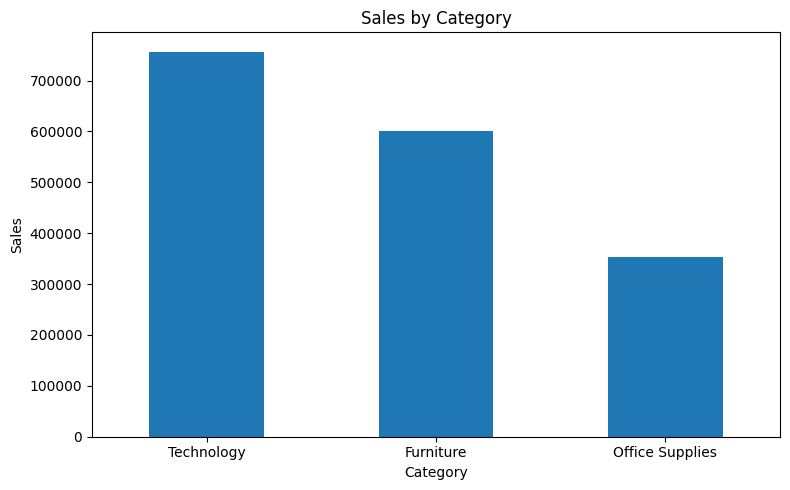

In [14]:
plt.figure(figsize=(8, 5))

sales_by_category.plot(kind="bar")

plt.title("Sales by Category")
plt.xlabel("Category")
plt.ylabel("Sales")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [15]:
profit_by_category = (
    df.groupby("Category")["Profit"]
    .sum()
    .sort_values(ascending=False)
)

display(profit_by_category)

,Profit
Category,
Technology,145068.68
Furniture,82188.95
Office Supplies,61662.81


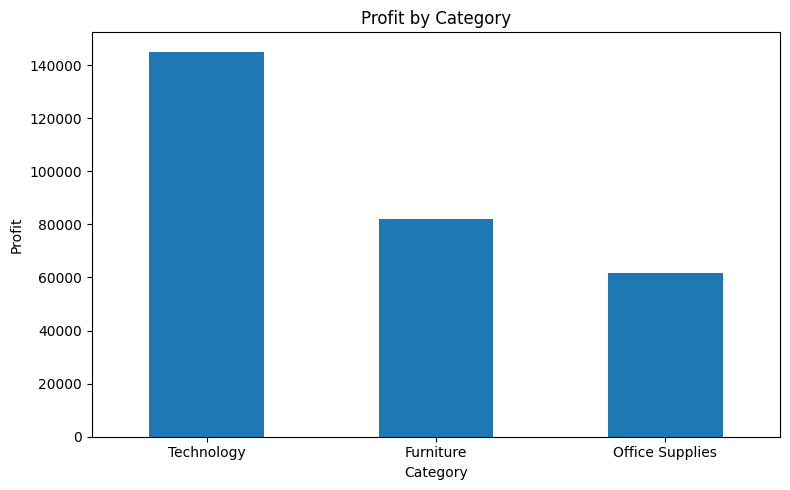

In [16]:
plt.figure(figsize=(8, 5))

profit_by_category.plot(kind="bar")

plt.title("Profit by Category")
plt.xlabel("Category")
plt.ylabel("Profit")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [17]:
sales_by_region = (
    df.groupby("Region")["Sales"]
    .sum()
    .sort_values(ascending=False)
)

display(sales_by_region)

,Sales
Region,
Western Europe,259576.28
Oceania,220809.08
Southern Asia,205466.26
Eastern Asia,193590.60
Southeastern Asia,147337.60
Central America,140966.21
Northern Europe,103888.63
Southern Europe,94441.11
South America,64550.54


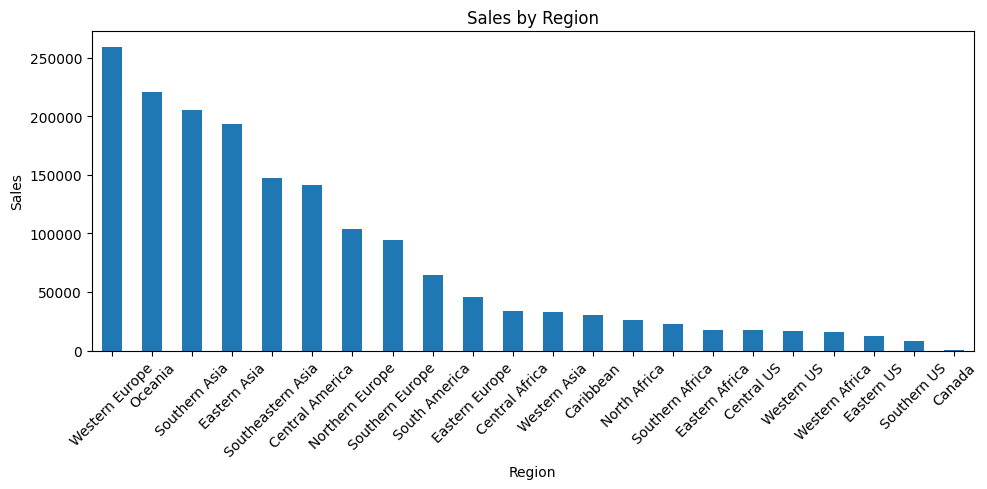

In [18]:
plt.figure(figsize=(10, 5))

sales_by_region.plot(kind="bar")

plt.title("Sales by Region")
plt.xlabel("Region")
plt.ylabel("Sales")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 5. Top Product Analysis

Identifying the highest-selling products helps understand which
products contribute most to overall sales.

In [19]:
top_products = (
    df.groupby("Product Name")["Sales"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

display(top_products)

,Sales
Product Name,
"Motorola Smart Phone, Full Size",48542.52
"Apple Smart Phone, Full Size",42303.44
"Cisco Smart Phone, Full Size",41325.20
"Nokia Smart Phone, Full Size",27661.97
"Samsung Smart Phone, Cordless",25438.59
"Hoover Stove, Red",23477.81
"Motorola Smart Phone, with Caller ID",23239.44
"Harbour Creations Executive Leather Armchair, Adjustable",22145.80
"Cisco Smart Phone, with Caller ID",22047.89


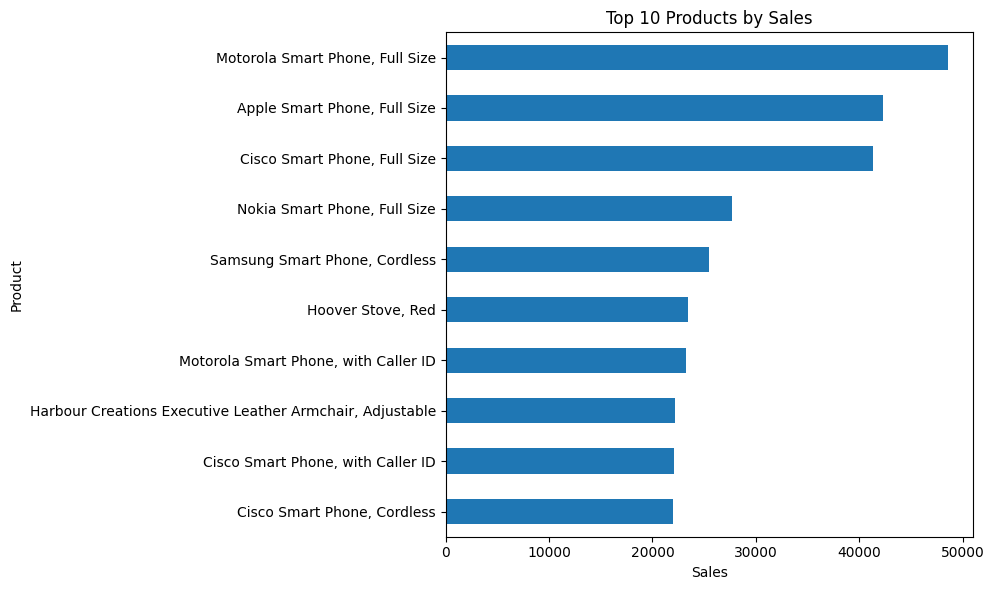

In [20]:
plt.figure(figsize=(10, 6))

top_products.sort_values().plot(kind="barh")

plt.title("Top 10 Products by Sales")
plt.xlabel("Sales")
plt.ylabel("Product")
plt.tight_layout()
plt.show()

## 6. Discount and Profit Analysis

We will examine the relationship between discount and profit.

This can help us understand whether higher discounts are associated
with changes in profitability.

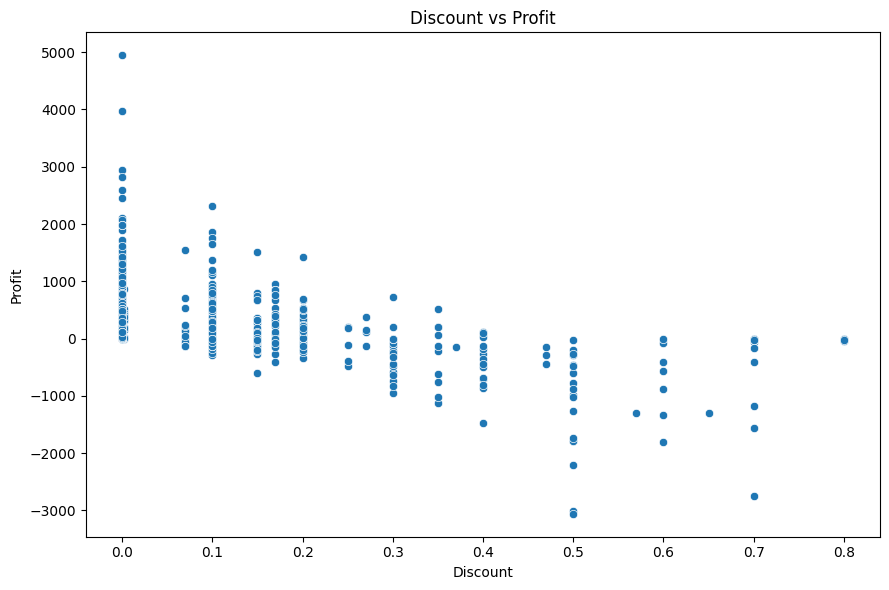

In [21]:
plt.figure(figsize=(9, 6))

sns.scatterplot(
    data=df,
    x="Discount",
    y="Profit"
)

plt.title("Discount vs Profit")
plt.xlabel("Discount")
plt.ylabel("Profit")
plt.tight_layout()
plt.show()

In [22]:
numeric_columns = [
    "Sales",
    "Quantity",
    "Discount",
    "Profit"
]

correlation = df[numeric_columns].corr()

display(correlation)

,Sales,Quantity,Discount,Profit
Sales,1.000000,0.555691,-0.187997,0.533676
Quantity,0.555691,1.000000,0.034045,0.154481
Discount,-0.187997,0.034045,1.000000,-0.505190
Profit,0.533676,0.154481,-0.505190,1.000000


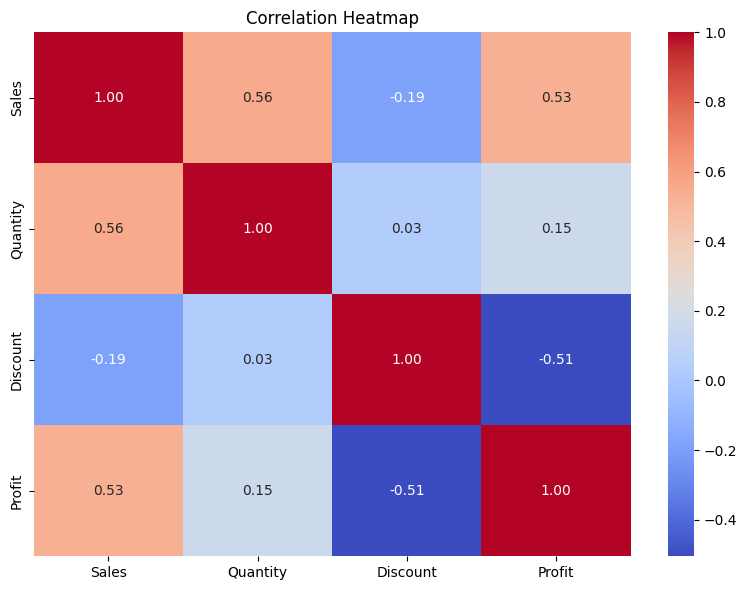

In [23]:
plt.figure(figsize=(8, 6))

sns.heatmap(
    correlation,
    annot=True,
    fmt=".2f",
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()

# 7. Machine Learning

In this project, Machine Learning will be used to predict Profit.

The following features will be used:

- Sales
- Quantity
- Discount
- Shipping Cost

The target variable is:

- Profit

We will compare two regression models:

1. Linear Regression
2. Random Forest Regression

In [24]:
features = [
    "Sales",
    "Quantity",
    "Discount",
    "Shipping Cost"
]

target = "Profit"

ml_data = df[features + [target]].dropna()

X = ml_data[features]
y = ml_data[target]

print("Machine Learning dataset shape:", ml_data.shape)
display(ml_data.head())

Machine Learning dataset shape: (1000, 5)


,Sales,Quantity,Discount,Shipping Cost,Profit
0,221.98,2,0.0,40.77,62.15
1,3709.40,9,0.1,923.63,-288.77
2,5175.17,9,0.1,915.49,919.97
3,2892.51,5,0.1,910.16,-96.54
4,2832.96,8,0.0,903.04,311.52


## 8. Train-Test Split

The dataset will be divided into:

- 80% training data
- 20% testing data

The model learns patterns from the training data and is evaluated
using the unseen testing data.

In [25]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 800
Testing samples: 200


In [26]:
linear_model = LinearRegression()

linear_model.fit(
    X_train,
    y_train
)

linear_predictions = linear_model.predict(X_test)

print("Linear Regression model trained successfully.")

Linear Regression model trained successfully.


In [27]:
random_forest_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

random_forest_model.fit(
    X_train,
    y_train
)

random_forest_predictions = random_forest_model.predict(X_test)

print("Random Forest model trained successfully.")

Random Forest model trained successfully.


## 9. Model Evaluation

We will evaluate the models using:

### MAE
Mean Absolute Error measures the average absolute prediction error.

### RMSE
Root Mean Squared Error measures the typical prediction error while
giving greater weight to larger errors.

### R² Score
R² indicates how well the model explains variation in the target.

In [28]:
linear_mae = mean_absolute_error(
    y_test,
    linear_predictions
)

linear_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        linear_predictions
    )
)

linear_r2 = r2_score(
    y_test,
    linear_predictions
)


rf_mae = mean_absolute_error(
    y_test,
    random_forest_predictions
)

rf_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        random_forest_predictions
    )
)

rf_r2 = r2_score(
    y_test,
    random_forest_predictions
)

results = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Random Forest"
    ],
    "MAE": [
        linear_mae,
        rf_mae
    ],
    "RMSE": [
        linear_rmse,
        rf_rmse
    ],
    "R2 Score": [
        linear_r2,
        rf_r2
    ]
})

display(results.round(3))

,Model,MAE,RMSE,R2 Score
0,Linear Regression,282.434,371.272,0.521
1,Random Forest,231.447,315.813,0.653


## 10. Model Comparison

The two regression models are compared using MAE, RMSE, and R² Score.

A lower MAE and RMSE indicate lower prediction error.

A higher R² Score indicates better explanatory performance.

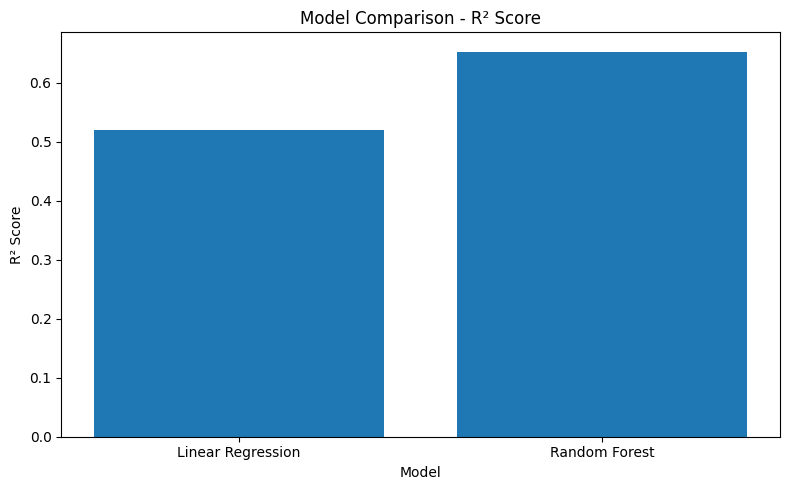

In [29]:
plt.figure(figsize=(8, 5))

plt.bar(
    results["Model"],
    results["R2 Score"]
)

plt.title("Model Comparison - R² Score")
plt.xlabel("Model")
plt.ylabel("R² Score")
plt.tight_layout()
plt.show()

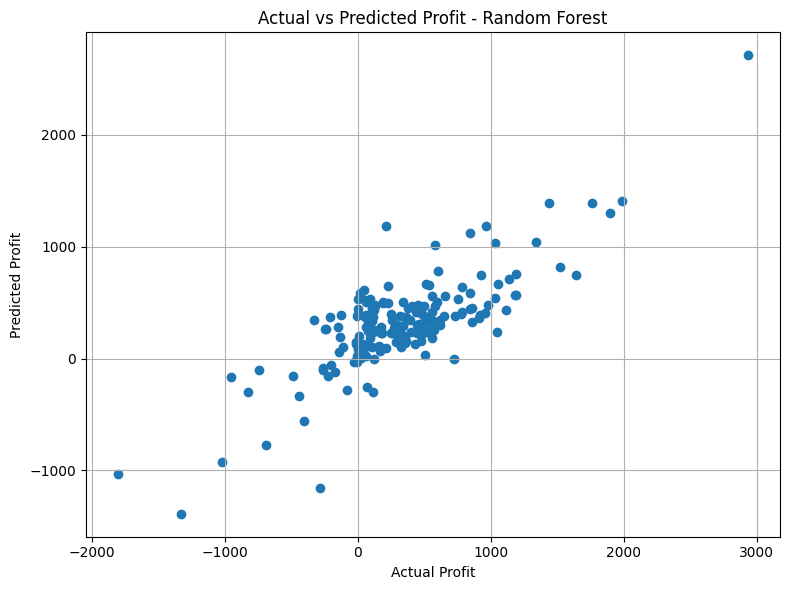

In [30]:
plt.figure(figsize=(8, 6))

plt.scatter(
    y_test,
    random_forest_predictions
)

plt.xlabel("Actual Profit")
plt.ylabel("Predicted Profit")
plt.title("Actual vs Predicted Profit - Random Forest")

plt.grid(True)
plt.tight_layout()
plt.show()

## 11. Feature Importance

Random Forest provides feature importance values.

These values help us understand which features contribute most to
the model's predictions.

In [ ]:
feature_importance = pd.DataFrame({
    "Feature": features,
    "Importance": random_forest_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    "Importance",
    ascending=False
)

display(feature_importance)

In [32]:
feature_importance = pd.DataFrame({
    "Feature": features,
    "Importance": random_forest_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    "Importance",
    ascending=False
)

display(feature_importance)

,Feature,Importance
0,Sales,0.506451
2,Discount,0.265162
3,Shipping Cost,0.132870
1,Quantity,0.095517


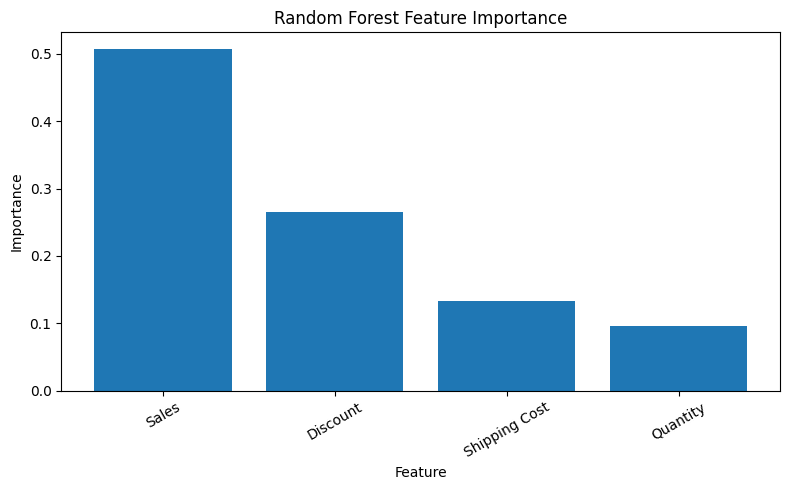

In [33]:
plt.figure(figsize=(8, 5))

plt.bar(
    feature_importance["Feature"],
    feature_importance["Importance"]
)

plt.title("Random Forest Feature Importance")
plt.xlabel("Feature")
plt.ylabel("Importance")
plt.xticks(rotation=30)

plt.tight_layout()
plt.show()

# 12. Key Business Insights

### Sales Insights

- Sales performance varies across product categories and regions.
- Top-performing products contribute significantly to overall sales.
- Sales trends can be studied over time to identify changes in demand.

### Profit Insights

- High sales do not always guarantee the highest profit.
- Discount levels can influence profitability.
- Profitability should be considered along with sales when evaluating
  business performance.

### Machine Learning Insights

- Linear Regression provides a simple baseline prediction model.
- Random Forest can capture more complex relationships between the
  input features and profit.
- Model performance was evaluated using MAE, RMSE, and R² Score.
- Feature importance helps identify which variables are most useful
  for predicting profit.

# 13. Final Conclusion

This project provided an end-to-end practical experience in Data
Science using a real-world retail dataset.

The project covered data loading, data cleaning, exploratory data
analysis, visualization, business insight generation, and Machine
Learning.

Two regression models, Linear Regression and Random Forest Regression,
were trained to predict profit.

The models were evaluated using MAE, RMSE, and R² Score.

This project demonstrates how Data Science and Machine Learning can
be used to analyze business data, discover meaningful patterns, and
support data-driven decision making.

## Skills Demonstrated

- Python Programming
- Pandas
- NumPy
- Data Cleaning
- Exploratory Data Analysis
- Data Visualization
- Statistical Analysis
- Machine Learning
- Linear Regression
- Random Forest Regression
- Model Evaluation
- Business Insights

# Module 6 Completed

## Final Data Science Project

**Project:** Global Superstore Sales Analysis and Profit Prediction

### Completed Tasks

✅ Data Collection  
✅ Data Cleaning  
✅ Exploratory Data Analysis  
✅ Data Visualization  
✅ Business Insights  
✅ Machine Learning  
✅ Linear Regression  
✅ Random Forest Regression  
✅ Model Evaluation  
✅ Feature Importance  
✅ Final Conclusion

### Technologies

Python | Pandas | NumPy | Matplotlib | Seaborn | Scikit-learn